In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ============================================================
# 1. Paths
# ============================================================

INPUT_PATH = Path("../data/processed/neutral_scoring_prepared/neutral_scoring_input_v1.tsv")

OUTPUT_DIR = Path("../results/directional_neutral_scoring_results_v4")
OUTPUT_DIR.mkdir(exist_ok=True)

SCORED_OUTPUT = OUTPUT_DIR / "directional_neutral_deviation_scores_v4.tsv"
THRESHOLD_OUTPUT = OUTPUT_DIR / "directional_neutral_deviation_thresholds_v4.tsv"
ENRICHMENT_OUTPUT = OUTPUT_DIR / "directional_posthoc_group_enrichment_v4.tsv"
TOP100_OUTPUT = OUTPUT_DIR / "top_100_directional_score_v4.tsv"
COMPONENT_SUMMARY_OUTPUT = OUTPUT_DIR / "directional_score_components_summary_v4.tsv"

# ============================================================
# 2. Load input
# ============================================================

df = pd.read_csv(INPUT_PATH, sep="\t", low_memory=False)

print("Input shape:", df.shape)

print("\nAnalysis group distribution:")
print(df["analysis_group"].value_counts(dropna=False))

Input shape: (49704, 40)

Analysis group distribution:
analysis_group
unlabeled_or_other            41280
neutral_reference              8284
article_pathogenic_posthoc       84
disease_suspected_posthoc        56
Name: count, dtype: int64


In [3]:
# ============================================================
# 3. Required columns
# ============================================================

id_cols = [
    "variant_id",
    "position",
    "reference",
    "alternate",
]

label_cols = [
    "validation_label",
    "is_neutral_dataset8",
    "is_pathogenic_dataset9",
    "is_disease_suspected_dataset3",
    "analysis_group",
]

required_feature_cols = [
    "mlc_score",
    "pop_af_max",
    "pop_af_hom_max",
]

required_cols = id_cols + label_cols + required_feature_cols

missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

work = df.copy()

for col in required_feature_cols:
    work[col] = pd.to_numeric(work[col], errors="coerce")

missing_summary = work[required_feature_cols].isna().sum()
missing_summary = missing_summary[missing_summary > 0]

if len(missing_summary) > 0:
    raise ValueError(f"Missing values in required features:\n{missing_summary}")

In [4]:
# ============================================================
# 4. Rank-based directional components
# ============================================================

eps = 1e-6

# Soft rarity
work["rarity_soft_raw"] = -np.log10(work["pop_af_max"] + eps)
work["rarity_soft_raw"] = work["rarity_soft_raw"].clip(lower=0, upper=6)

# No homoplasmic population signal
work["no_homoplasmic_component"] = (
    work["pop_af_hom_max"] == 0
).astype(int)

# Percentile ranks across all variants
# method="average" reduces arbitrary ordering inside ties.
work["mlc_percentile"] = work["mlc_score"].rank(
    method="average",
    pct=True,
)

work["rarity_percentile"] = work["rarity_soft_raw"].rank(
    method="average",
    pct=True,
)

# Directional rank-based score
work["directional_score_v4"] = (
    0.75 * work["mlc_percentile"]
    + 0.20 * work["rarity_percentile"]
    + 0.05 * work["no_homoplasmic_component"]
)

work["directional_score_v4_rank"] = (
    work["directional_score_v4"]
    .rank(method="min", ascending=False)
    .astype(int)
)

work["directional_score_v4_percentile"] = (
    work["directional_score_v4"]
    .rank(method="average", pct=True)
)

print("\nDirectional score v4 summary:")
print(work["directional_score_v4"].describe())

print("\nDirectional score v4 summary by analysis_group:")
print(
    work
    .groupby("analysis_group")["directional_score_v4"]
    .describe()
)

print("\nNumber of variants with max score:")
max_score = work["directional_score_v4"].max()
print((work["directional_score_v4"] == max_score).sum())

print("\nGroup composition among max-score variants:")
print(
    work.loc[
        work["directional_score_v4"] == max_score,
        "analysis_group"
    ].value_counts()
)


Directional score v4 summary:
count    49704.000000
mean         0.513287
std          0.252364
min          0.062067
25%          0.318220
50%          0.527801
75%          0.727236
max          0.917083
Name: directional_score_v4, dtype: float64

Directional score v4 summary by analysis_group:
                              count      mean       std       min       25%  \
analysis_group                                                                
article_pathogenic_posthoc     84.0  0.581428  0.171511  0.182754  0.467106   
disease_suspected_posthoc      56.0  0.458872  0.212365  0.170358  0.288227   
neutral_reference            8284.0  0.225085  0.180468  0.062067  0.081036   
unlabeled_or_other          41280.0  0.571058  0.223630  0.062100  0.407259   

                                 50%       75%       max  
analysis_group                                            
article_pathogenic_posthoc  0.604141  0.719516  0.867612  
disease_suspected_posthoc   0.417100  0.622313  0

In [5]:
# ============================================================
# 5. Thresholds based on neutral_reference
# ============================================================

neutral_mask = work["analysis_group"] == "neutral_reference"
neutral_scores = work.loc[neutral_mask, "directional_score_v4"]

threshold_rows = []

for q in [0.90, 0.95, 0.99]:
    threshold_name = f"T{int(q * 100)}"
    threshold = neutral_scores.quantile(q)

    flag_col = f"directional_score_v4_above_{threshold_name}"

    work[flag_col] = (
        work["directional_score_v4"] > threshold
    ).astype(int)

    threshold_rows.append({
        "score_name": "directional_score_v4",
        "threshold_name": threshold_name,
        "neutral_quantile": q,
        "threshold_value": threshold,
        "n_neutral_above_threshold": int(work.loc[neutral_mask, flag_col].sum()),
        "fraction_neutral_above_threshold": float(work.loc[neutral_mask, flag_col].mean()),
    })

threshold_df = pd.DataFrame(threshold_rows)

print("\nThresholds:")
print(threshold_df)

threshold_df.to_csv(THRESHOLD_OUTPUT, sep="\t", index=False)
print("\nSaved thresholds:", THRESHOLD_OUTPUT)


Thresholds:
             score_name threshold_name  neutral_quantile  threshold_value  \
0  directional_score_v4            T90              0.90         0.495502   
1  directional_score_v4            T95              0.95         0.616950   
2  directional_score_v4            T99              0.99         0.841450   

   n_neutral_above_threshold  fraction_neutral_above_threshold  
0                        828                          0.099952  
1                        415                          0.050097  
2                         83                          0.010019  

Saved thresholds: ../results/directional_neutral_scoring_results_v4/directional_neutral_deviation_thresholds_v4.tsv


In [6]:
# ============================================================
# 6. Post-hoc enrichment
# ============================================================

posthoc_groups = [
    "neutral_reference",
    "unlabeled_or_other",
    "article_pathogenic_posthoc",
    "disease_suspected_posthoc",
]

expected_fraction = {
    "T90": 0.10,
    "T95": 0.05,
    "T99": 0.01,
}

enrichment_rows = []

for threshold_name in ["T90", "T95", "T99"]:
    flag_col = f"directional_score_v4_above_{threshold_name}"
    expected = expected_fraction[threshold_name]

    for group in posthoc_groups:
        group_mask = work["analysis_group"] == group

        n_group = int(group_mask.sum())
        n_above = int(work.loc[group_mask, flag_col].sum())
        frac_above = n_above / n_group if n_group > 0 else np.nan

        enrichment_rows.append({
            "score_name": "directional_score_v4",
            "threshold_name": threshold_name,
            "analysis_group": group,
            "n_group": n_group,
            "n_above_threshold": n_above,
            "fraction_above_threshold": frac_above,
            "expected_neutral_fraction": expected,
            "fold_enrichment_vs_neutral_expectation": (
                frac_above / expected if expected > 0 else np.nan
            ),
        })

enrichment_df = pd.DataFrame(enrichment_rows)

print("\nPost-hoc enrichment:")
print(enrichment_df)

enrichment_df.to_csv(ENRICHMENT_OUTPUT, sep="\t", index=False)
print("\nSaved enrichment:", ENRICHMENT_OUTPUT)


Post-hoc enrichment:
              score_name threshold_name              analysis_group  n_group  \
0   directional_score_v4            T90           neutral_reference     8284   
1   directional_score_v4            T90          unlabeled_or_other    41280   
2   directional_score_v4            T90  article_pathogenic_posthoc       84   
3   directional_score_v4            T90   disease_suspected_posthoc       56   
4   directional_score_v4            T95           neutral_reference     8284   
5   directional_score_v4            T95          unlabeled_or_other    41280   
6   directional_score_v4            T95  article_pathogenic_posthoc       84   
7   directional_score_v4            T95   disease_suspected_posthoc       56   
8   directional_score_v4            T99           neutral_reference     8284   
9   directional_score_v4            T99          unlabeled_or_other    41280   
10  directional_score_v4            T99  article_pathogenic_posthoc       84   
11  directional_sc

In [7]:
# ============================================================
# 7. Save scored table
# ============================================================

output_cols = [
    "variant_id",
    "position",
    "reference",
    "alternate",
    "validation_label",
    "is_neutral_dataset8",
    "is_pathogenic_dataset9",
    "is_disease_suspected_dataset3",
    "analysis_group",

    "mlc_score",
    "pop_af_max",
    "pop_af_hom_max",

    "rarity_soft_raw",
    "no_homoplasmic_component",
    "mlc_percentile",
    "rarity_percentile",

    "directional_score_v4",
    "directional_score_v4_rank",
    "directional_score_v4_percentile",

    "directional_score_v4_above_T90",
    "directional_score_v4_above_T95",
    "directional_score_v4_above_T99",
]

work[output_cols].to_csv(SCORED_OUTPUT, sep="\t", index=False)

print("\nSaved scored table:")
print(SCORED_OUTPUT)


Saved scored table:
../results/directional_neutral_scoring_results_v4/directional_neutral_deviation_scores_v4.tsv


In [8]:
# ============================================================
# 8. Top-100 variants
# ============================================================

top_100 = (
    work[output_cols]
    .sort_values("directional_score_v4", ascending=False)
    .head(100)
)

top_100.to_csv(TOP100_OUTPUT, sep="\t", index=False)

print("\nSaved top 100:")
print(TOP100_OUTPUT)

print("\nTop 30 variants:")
print(
    top_100[
        [
            "variant_id",
            "analysis_group",
            "directional_score_v4",
            "mlc_score",
            "mlc_percentile",
            "pop_af_max",
            "rarity_soft_raw",
            "rarity_percentile",
            "no_homoplasmic_component",
            "directional_score_v4_above_T95",
            "directional_score_v4_above_T99",
        ]
    ].head(30)
)


Saved top 100:
../results/directional_neutral_scoring_results_v4/top_100_directional_score_v4.tsv

Top 30 variants:
       variant_id      analysis_group  directional_score_v4  mlc_score  \
29782   m.9929C>A  unlabeled_or_other              0.917083        1.0   
30239  m.10081T>G  unlabeled_or_other              0.917083        1.0   
30211  m.10072T>A  unlabeled_or_other              0.917083        1.0   
29938   m.9981T>A  unlabeled_or_other              0.917083        1.0   
29929   m.9978T>A  unlabeled_or_other              0.917083        1.0   
29927   m.9977T>G  unlabeled_or_other              0.917083        1.0   
29926   m.9977T>A  unlabeled_or_other              0.917083        1.0   
29891   m.9965T>G  unlabeled_or_other              0.917083        1.0   
29890   m.9965T>A  unlabeled_or_other              0.917083        1.0   
29851   m.9952G>A  unlabeled_or_other              0.917083        1.0   
29848   m.9951T>A  unlabeled_or_other              0.917083        1.

In [9]:
# ============================================================
# 9. Component summary by group
# ============================================================

summary_rows = []

component_summary_cols = [
    "mlc_score",
    "pop_af_max",
    "pop_af_hom_max",
    "rarity_soft_raw",
    "no_homoplasmic_component",
    "mlc_percentile",
    "rarity_percentile",
    "directional_score_v4",
]

for group in posthoc_groups:
    group_df = work[work["analysis_group"] == group]

    for col in component_summary_cols:
        summary_rows.append({
            "analysis_group": group,
            "feature": col,
            "n": int(group_df[col].notna().sum()),
            "mean": float(group_df[col].mean()),
            "median": float(group_df[col].median()),
            "q25": float(group_df[col].quantile(0.25)),
            "q75": float(group_df[col].quantile(0.75)),
            "min": float(group_df[col].min()),
            "max": float(group_df[col].max()),
        })

component_summary = pd.DataFrame(summary_rows)

component_summary.to_csv(
    COMPONENT_SUMMARY_OUTPUT,
    sep="\t",
    index=False,
)

print("\nSaved component summary:")
print(COMPONENT_SUMMARY_OUTPUT)


Saved component summary:
../results/directional_neutral_scoring_results_v4/directional_score_components_summary_v4.tsv


In [10]:
import matplotlib.pyplot as plt
import numpy as np

analysis_group_order = [
    "neutral_reference",
    "unlabeled_or_other",
    "article_pathogenic_posthoc",
    "disease_suspected_posthoc",
]

analysis_group_labels = {
    "neutral_reference": "Neutral reference",
    "unlabeled_or_other": "Unlabeled / other",
    "article_pathogenic_posthoc": "Article pathogenic post-hoc",
    "disease_suspected_posthoc": "Disease suspected post-hoc",
}

def plot_score_v4_distribution(work, threshold_df):
    score_col = "directional_score_v4"

    plt.figure(figsize=(10, 6))

    for group in analysis_group_order:
        subset = work.loc[
            work["analysis_group"] == group,
            score_col
        ].dropna()

        if len(subset) == 0:
            continue

        plt.hist(
            subset,
            bins=60,
            density=True,
            alpha=0.45,
            label=f"{analysis_group_labels[group]} (n={len(subset)})",
        )

    for threshold_name in ["T90", "T95", "T99"]:
        threshold_value = threshold_df.loc[
            threshold_df["threshold_name"] == threshold_name,
            "threshold_value"
        ].iloc[0]

        plt.axvline(
            threshold_value,
            linestyle="--",
            linewidth=1,
            label=threshold_name,
        )

    plt.xlabel("Directional score v4")
    plt.ylabel("Density")
    plt.title("Directional score v4 distribution by group")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_enrichment_v4(enrichment_df, threshold_name):
    plot_df = enrichment_df[
        enrichment_df["threshold_name"] == threshold_name
    ].copy()

    plot_df = (
        plot_df
        .set_index("analysis_group")
        .loc[analysis_group_order]
        .reset_index()
    )

    x = np.arange(plot_df.shape[0])
    y = plot_df["fraction_above_threshold"].values

    plt.figure(figsize=(9, 5))
    plt.bar(x, y)

    plt.axhline(
        {"T90": 0.10, "T95": 0.05, "T99": 0.01}[threshold_name],
        linestyle="--",
        linewidth=1,
        label=f"Neutral expectation: {threshold_name}",
    )

    plt.xticks(
        x,
        [analysis_group_labels[g] for g in plot_df["analysis_group"]],
        rotation=30,
        ha="right",
    )

    plt.ylabel("Fraction above threshold")
    plt.title(f"Directional score v4: fraction above {threshold_name}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_v4_components(work):
    component_cols = [
        "mlc_percentile",
        "rarity_percentile",
        "no_homoplasmic_component",
    ]

    for col in component_cols:
        plt.figure(figsize=(10, 5))

        for group in analysis_group_order:
            subset = work.loc[
                work["analysis_group"] == group,
                col
            ].dropna()

            if len(subset) == 0:
                continue

            plt.hist(
                subset,
                bins=60,
                density=True,
                alpha=0.45,
                label=f"{analysis_group_labels[group]}",
            )

        plt.xlabel(col)
        plt.ylabel("Density")
        plt.title(f"Component distribution: {col}")
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.show()


def plot_v4_top_tail(work, threshold_df, top_n=1000):
    top_df = (
        work
        .sort_values("directional_score_v4", ascending=False)
        .head(top_n)
        .copy()
    )

    top_df["rank_in_top"] = np.arange(1, top_df.shape[0] + 1)

    plt.figure(figsize=(10, 5))

    plt.plot(
        top_df["rank_in_top"],
        top_df["directional_score_v4"],
        linewidth=1,
    )

    for threshold_name in ["T90", "T95", "T99"]:
        threshold_value = threshold_df.loc[
            threshold_df["threshold_name"] == threshold_name,
            "threshold_value"
        ].iloc[0]

        plt.axhline(
            threshold_value,
            linestyle="--",
            linewidth=1,
            label=threshold_name,
        )

    plt.xlabel(f"Rank among top {top_n} variants")
    plt.ylabel("Directional score v4")
    plt.title("Top-tail profile: directional score v4")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

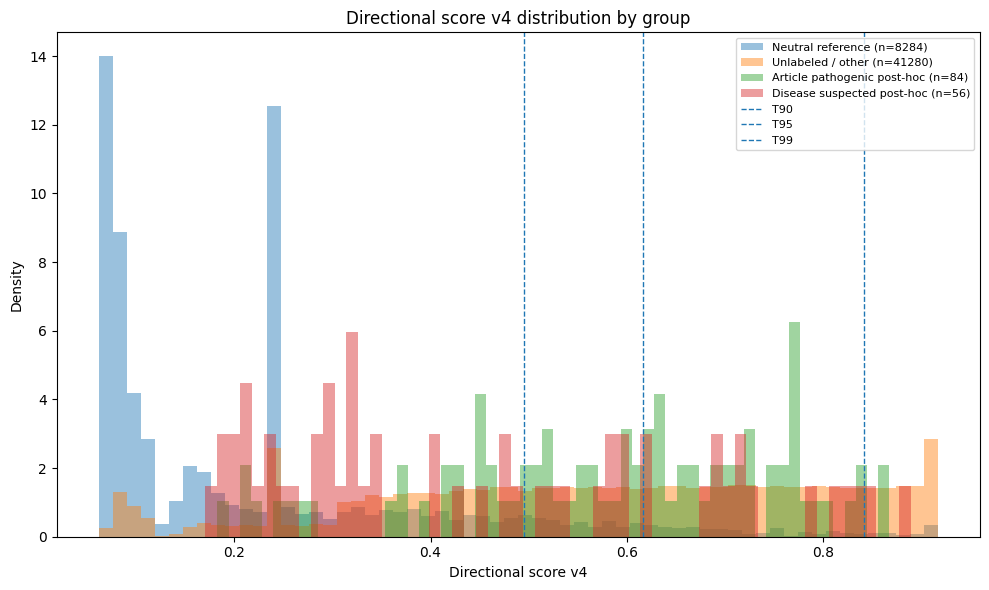

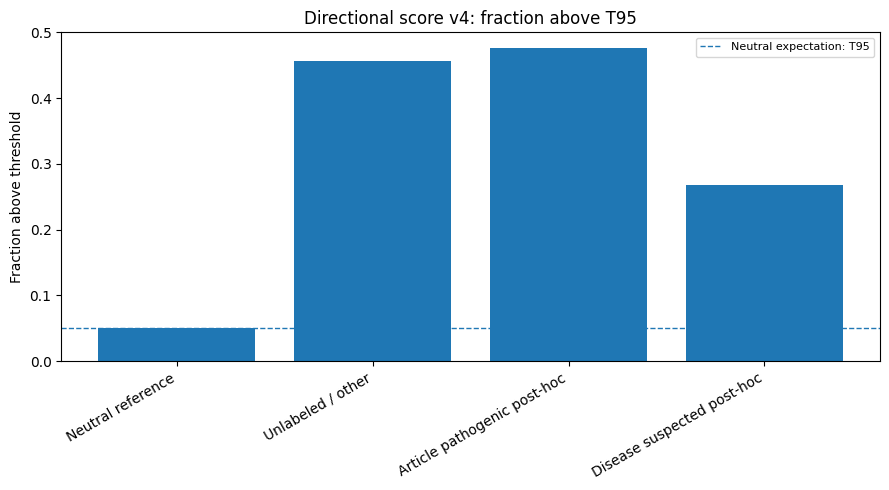

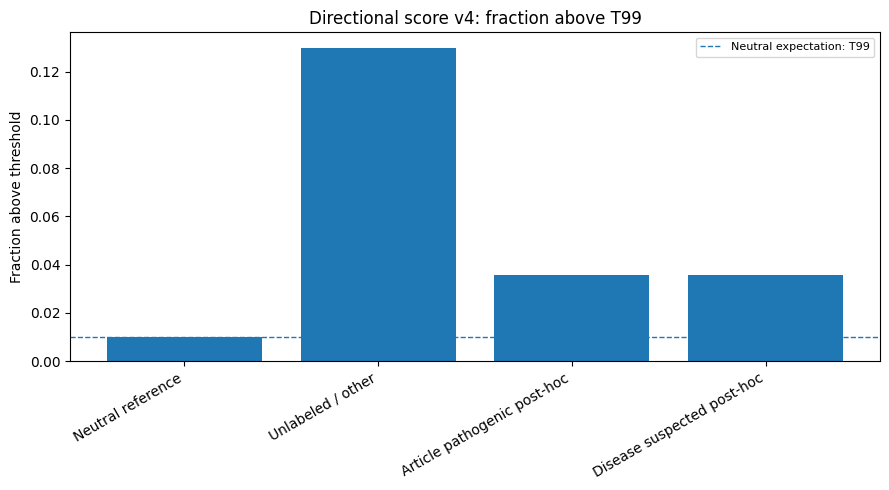

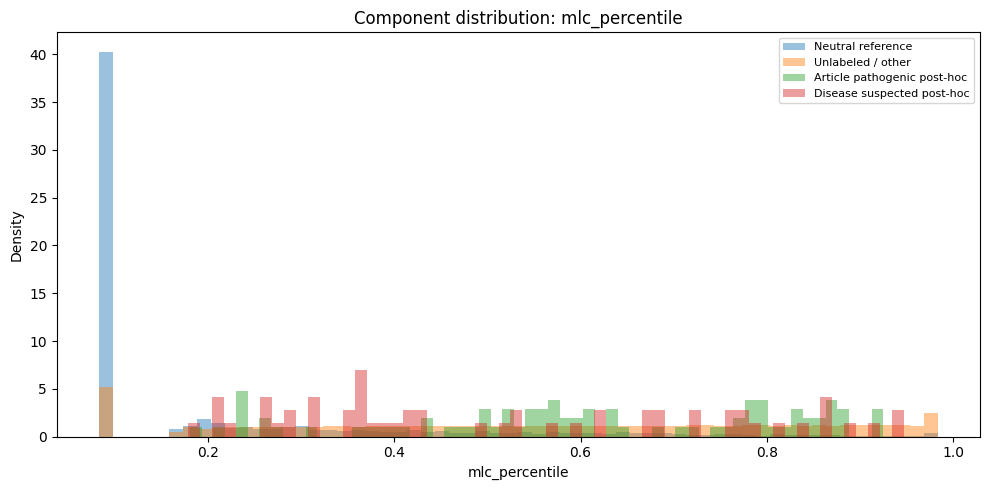

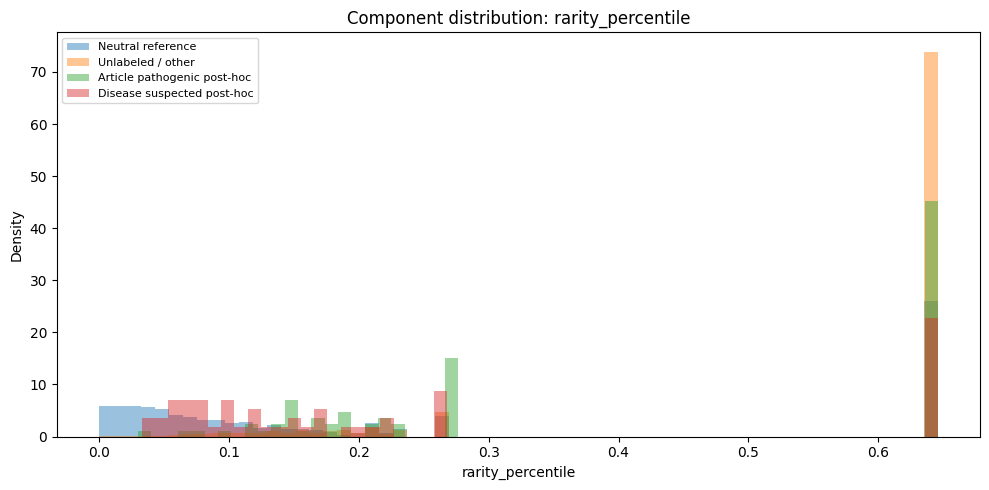

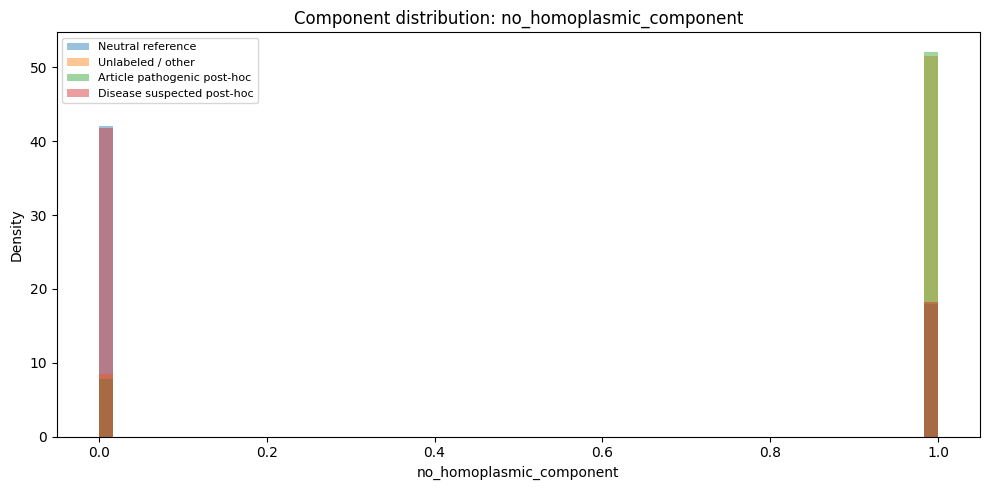

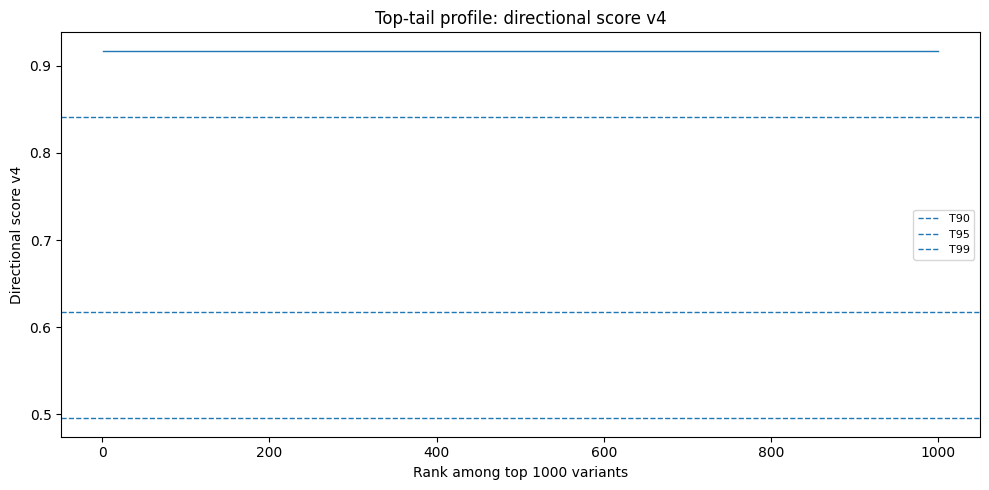

In [11]:
plot_score_v4_distribution(work, threshold_df)
plot_enrichment_v4(enrichment_df, "T95")
plot_enrichment_v4(enrichment_df, "T99")
plot_v4_components(work)
plot_v4_top_tail(work, threshold_df, top_n=1000)